# Parte 1 - Algoritmo para detección de logo

Obtener una detección del logo en cada imagen sin falsos positivos.

In [1]:
import cv2 as cv
import supervision as sv
import numpy as np

Lo primero que hacemos es mirar el template en escala de grises:

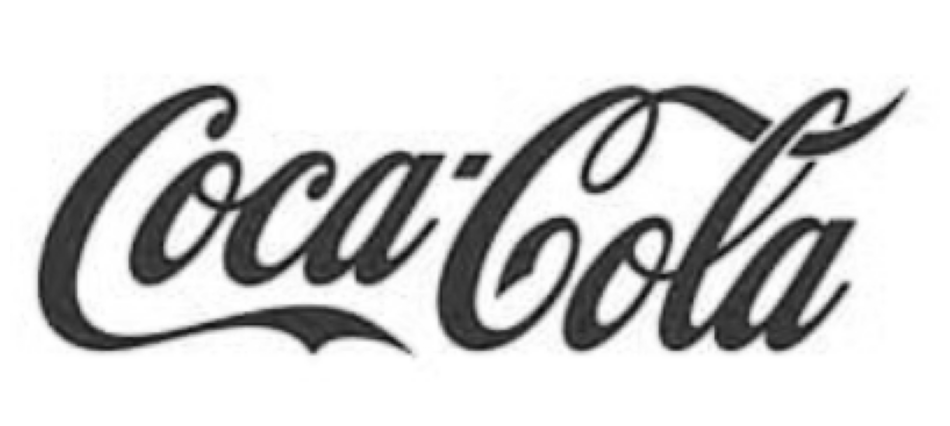

In [2]:
template_raw = cv.imread('material/template/pattern.png', cv.IMREAD_GRAYSCALE)
sv.plot_image(template_raw)

Podemos recortar la imágen para eliminar los márgenes innecesarios.

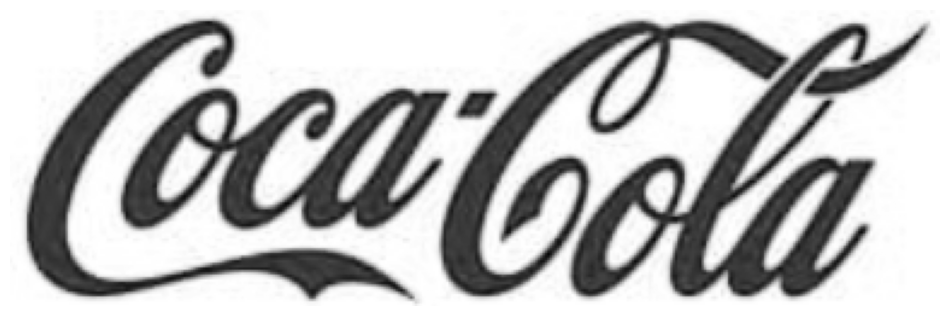

In [3]:
_, thresh = cv.threshold(template_raw, 250, 255, cv.THRESH_BINARY_INV)
x, y, w, h = cv.boundingRect(thresh)
template_cropped = template_raw[y:y+h, x:x+w]
sv.plot_image(template_cropped)

Además, en la mayoría de las imágenes donde debemos encontrar el logo, los colores con respecto al template están invertidos. Por lo cual, previamente convertimos la imágen a blanco y negro estrictos, y ahora procedemos a invertir los colores:

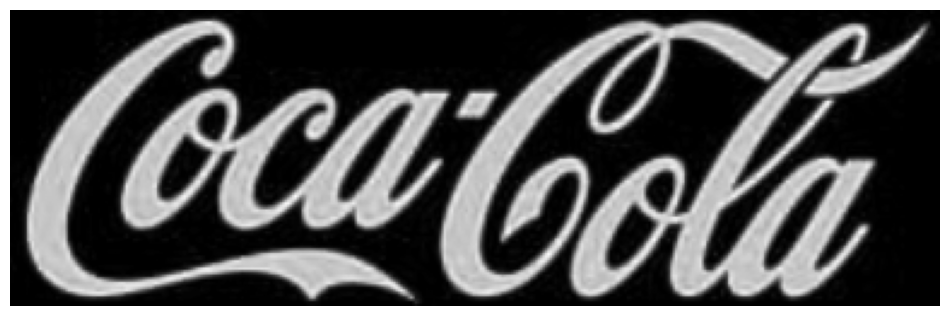

In [4]:
template = 255 - template_cropped
sv.plot_image(template)

Finalmente, usamos Clahe para mejorar los bordes:

In [5]:
clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
template = clahe.apply(template)

Procedemos a aplicar el pre-procesamiento a un target a modo de ejemplo:

In [6]:
target_raw = cv.imread("material/images/coca_logo_1.png", cv.IMREAD_GRAYSCALE)
target = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(target_raw)

Encontramos los key points y descriptores tanto para el template como para el target, usando SIFT:

In [7]:
kp_template, des_template = cv.SIFT_create().detectAndCompute(template, None)
kp_target, des_target = cv.SIFT_create().detectAndCompute(target, None)

Procedemos a encontrar los matches entre ambos conjuntos de descriptores:

In [8]:
bf = cv.BFMatcher(cv.NORM_L2)
matches = bf.knnMatch(des_template, des_target, k=2)

# Lowe test
good = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good.append(m)

Intentamos construir la homografía:

In [10]:
MIN_MATCH_COUNT = 4

img_color = cv.cvtColor(target, cv.COLOR_GRAY2BGR)
if len(good) >= MIN_MATCH_COUNT:
    src_pts = np.float32([kp_template[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp_target[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)

    M, mask = cv.findHomography(src_pts, dst_pts, cv.RANSAC, 5.0)
    if M is not None:
        matchesMask = mask.ravel().tolist()
        good_inliers = [m for i, m in enumerate(good) if matchesMask[i]]

        # Proyectar el área del patrón sobre la imagen destino
        h_t, w_t = template.shape
        box = np.float32([[0,0], [0,h_t], [w_t,h_t], [w_t,0]]).reshape(-1,1,2)
        projected = cv.perspectiveTransform(box, M)
        cv.polylines(img_color, [np.int32(projected)], True, (0, 255, 0), 3, cv.LINE_AA)
    else:
        print("No se pudo estimar homografía.")
        good_inliers = []
else:
    print(f"Insuficientes matches válidos: {len(good)} / {MIN_MATCH_COUNT}")
    good_inliers = []

Finalmente, graficamos:

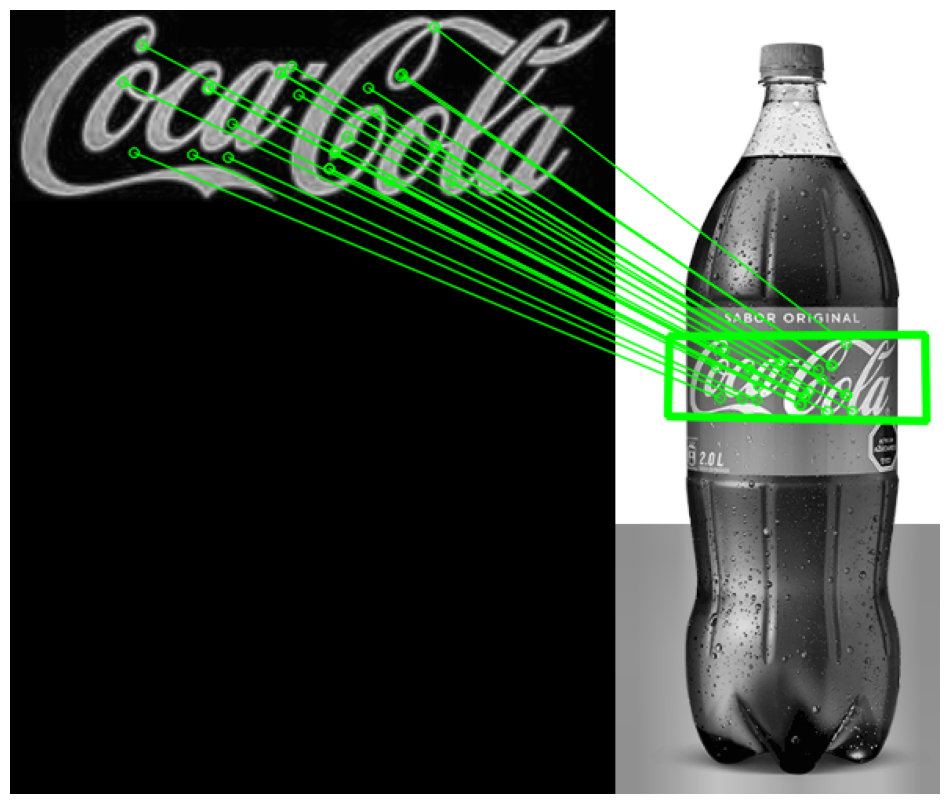

In [11]:
draw_params = dict(matchColor=(0, 255, 0),
                   singlePointColor=None,
                   matchesMask=None,
                   flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

img_out = cv.drawMatches(template, kp_template, img_color, kp_target, good_inliers, None, **draw_params)

sv.plot_image(img_out)

A partir de aquí, logramos diseñar el algoritmo provisto en la clase **SingleLogoDetector**.

A continuación se detalla todos los pasos provistos por esta clase:

#### 1. **Inicialización**
Al crear una instancia de la clase, se cargan las rutas de la plantilla (el logotipo recortado) y la imagen objetivo (donde se desea buscar el logotipo).

#### 2. **Carga y preprocesamiento de la plantilla**
La imagen de la plantilla se carga y convierte a escala de grises. Luego se recorta automáticamente para eliminar bordes blancos. Se pueden aplicar dos procesos opcionales:
- Inversión de colores.
- Ecualización del histograma para mejorar el contraste en áreas uniformes.

#### 3. **Preprocesamiento de la imagen objetivo**
La imagen donde se desea detectar el logotipo también se convierte a escala de grises. Luego se aplica ecualización adaptativa para mejorar el contraste.

#### 4. **Extracción de características (keypoints)**
Tanto en la plantilla como en la imagen objetivo se detectan puntos clave visuales (keypoints) y se calculan sus descriptores usando un algoritmo robusto a escala y rotación (SIFT).

#### 5. **Ajuste de coordenadas**
Los puntos clave de la plantilla son ajustados según el recorte realizado previamente, de modo que sus coordenadas sean consistentes con la imagen original.

#### 6. **Emparejamiento de características**
Se comparan los descriptores de la plantilla con los de la imagen objetivo. Se seleccionan las mejores coincidencias utilizando una técnica conocida como “ratio test” que filtra coincidencias ambiguas.

#### 7. **Cálculo de la homografía**
Si se encuentran suficientes coincidencias válidas, se calcula una transformación geométrica (homografía) que permite estimar cómo se proyecta el logotipo en la imagen objetivo.

#### 8. **Evaluación de confianza**
Se calcula una métrica de confianza basada en la proporción de coincidencias válidas con respecto al total de coincidencias encontradas. Esto da una idea de qué tan confiable es la detección.

#### 9. **Visualización del resultado**
Se dibujan sobre la imagen objetivo:
- El contorno del logotipo proyectado.
- Las líneas que unen puntos clave coincidentes.
- El porcentaje de confianza estimado.

Todo esto se muestra como resultado final para que el usuario pueda verificar visualmente la detección.

El método principal de ejecución realiza todos los pasos anteriores. Además, prueba dos versiones de la plantilla (original e invertida) para elegir la que tenga mejor desempeño en coincidencias.

Este algoritmo resuelve la detección del logo para todos los ejemplos provistos, e incluso, lo hace para una imagen extraída de internet, en la que el logo se encuentra rotado. En dicho ejemplo se evidencia la potencia de los descriptores y de la construcción de la homografía.

In [12]:
from pathlib import Path
from itertools import chain
from single_logo_detector import SingleLogoDetector

Procesando: COCA-COLA-LOGO.jpg
Mejor variante: invertido con 28 matches.


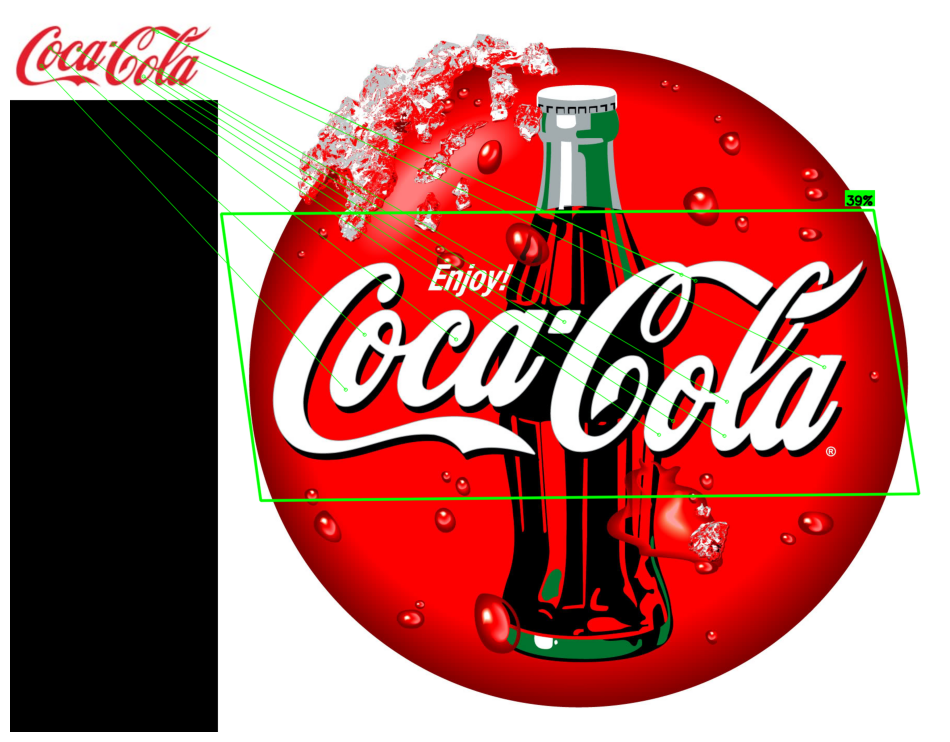

Procesando: coca.png
Mejor variante: invertido con 47 matches.


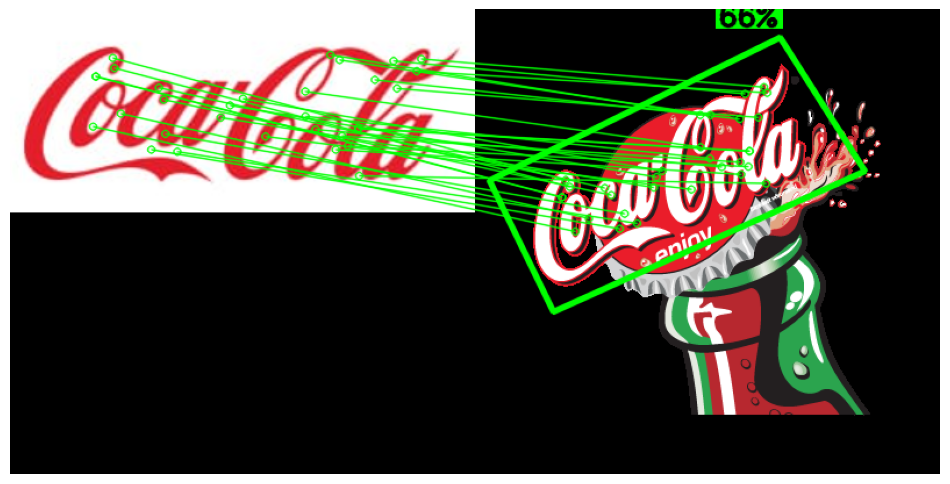

Ignorado: coca_multi.png
Procesando: coca_logo_1.png
Mejor variante: invertido con 39 matches.


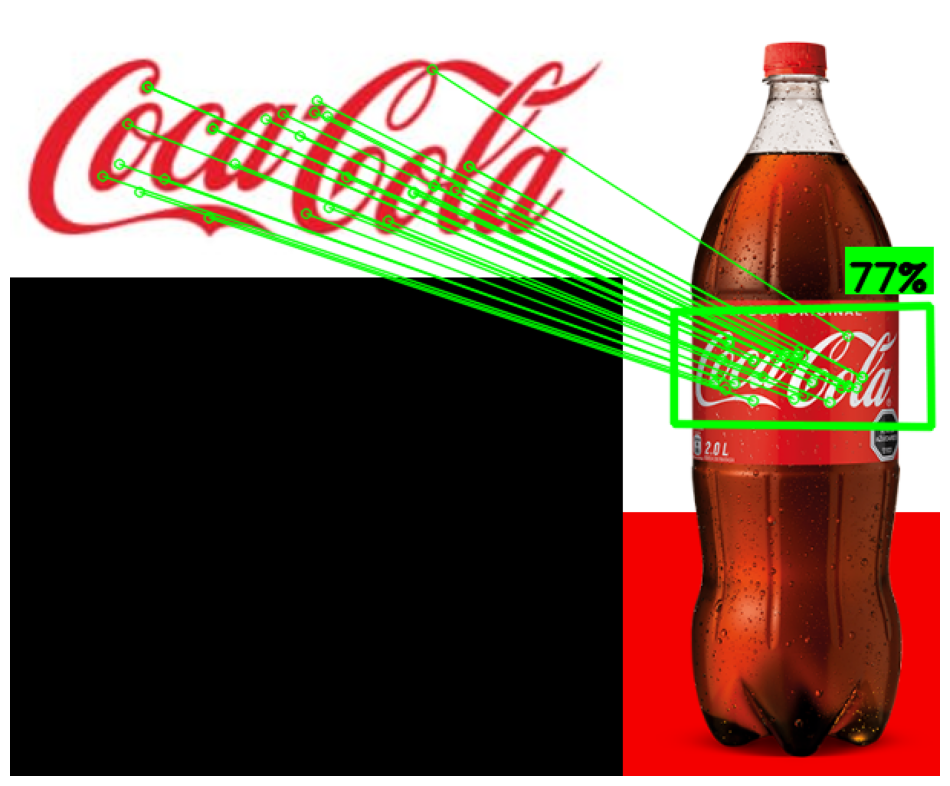

Procesando: coca_retro_1.png
Mejor variante: normal con 27 matches.


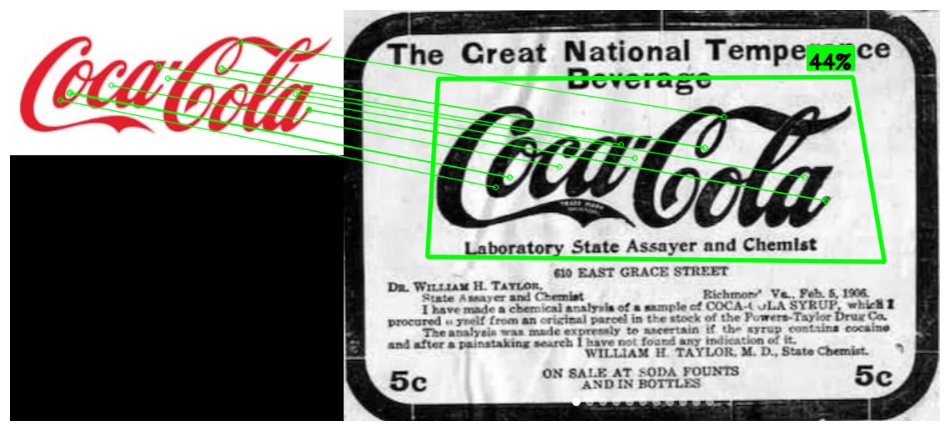

Procesando: logo_1.png
Mejor variante: invertido con 34 matches.


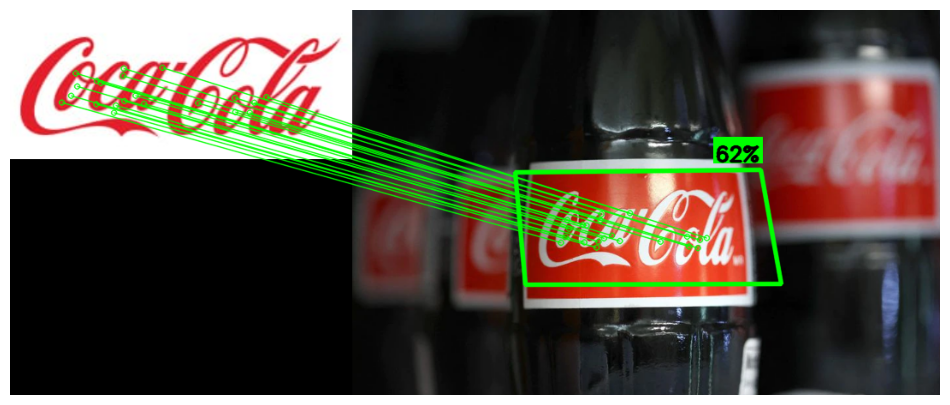

Procesando: coca_logo_2.png
Mejor variante: invertido con 35 matches.


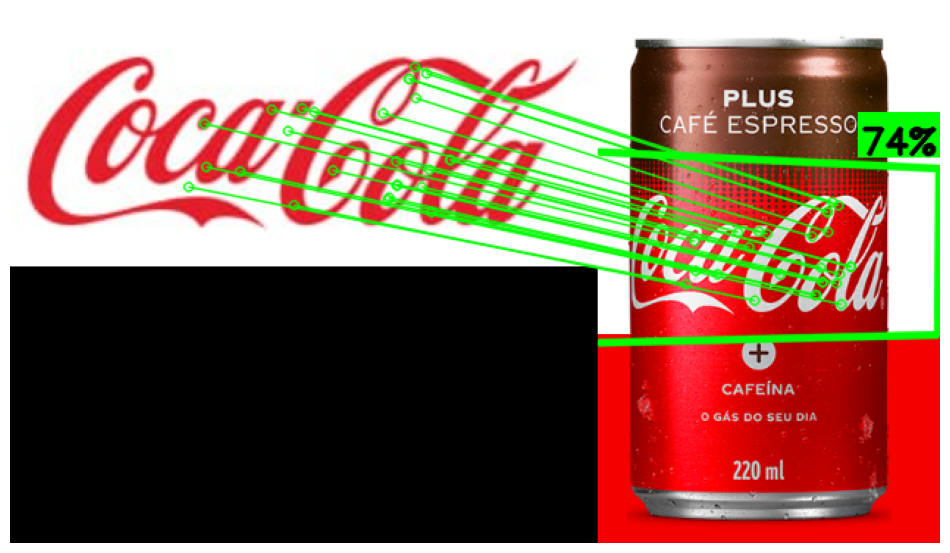

Procesando: coca_retro_2.png
Mejor variante: invertido con 19 matches.


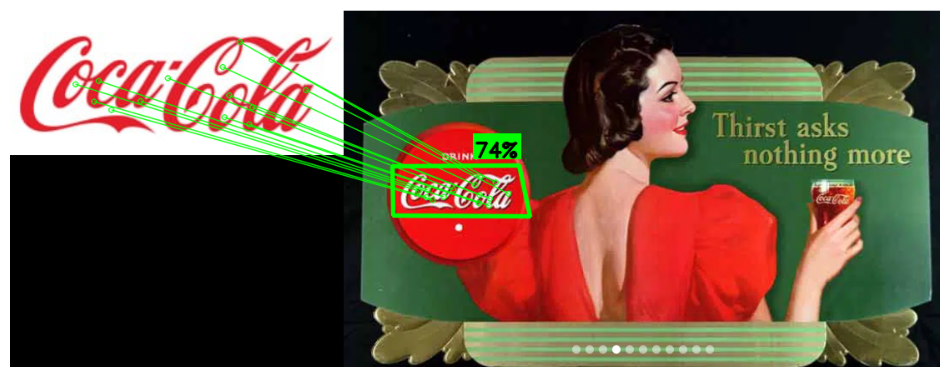

In [13]:
# Rutas
template_path = "material/template/pattern.png"
folder_path = Path("material/images")

image_files = chain(folder_path.glob("*.jpg"), folder_path.glob("*.png"))

# Iterar sobre imágenes en la carpeta, ignorando "coca_multi.png"
for target_file in image_files:
    if "coca_multi" in target_file.stem:
        print(f"Ignorado: {target_file.name}")
        continue

    print(f"Procesando: {target_file.name}")
    matcher = SingleLogoDetector(str(template_path), str(target_file))
    matcher.run()